<a href="https://colab.research.google.com/github/myriosMin/SP500-News-Sentiment-Analysis/blob/main/NewsSentimentAnalysis_RiskAssessment%5BMin%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# usual imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# to get finance data from yahoo finance
import yfinance as yf

# to download data directly from Kaggle
!pip install opendatasets
import opendatasets as od

# language models
import spacy
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
import re

# ml models
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR

# progress bar
from tqdm.notebook import tqdm

# miscellaneous
import ast
import random

#Cointegration

## Getting company names of top S&P500

In [ ]:
# get the names and tickers of S&P500 companies
sp500_url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
sp500_table = pd.read_html(sp500_url, header=0)
sp500_df = sp500_table[0]
sp500_df.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [ ]:
# get the top 20 companies by current market capitalization
top20 = {}

for ticker in tqdm(sp500_df['Symbol'], desc="Processing Tickers"):
    try:
        top20[ticker] = yf.Ticker(ticker).info['marketCap'] #1min to run
    except:
        pass

top20 = pd.DataFrame.from_dict(top20, orient='index', columns=['market_cap'])
top20 = top20.sort_values(by='market_cap', ascending=False).head(20)
top20

Processing Tickers:   0%|          | 0/503 [00:00<?, ?it/s]

,market_cap
AAPL,3287734812672
MSFT,3017962684416
NVDA,2576672096256
GOOG,2024390131712
GOOGL,2024385150976
AMZN,1752135368704
META,1309864886272
LLY,802891825152
AVGO,690132418560
TSLA,638927962112


In [ ]:
# get the names of the top 20 companies
top20 = top20.merge(sp500_df[['Symbol', 'Security', 'GICS Sector', 'Headquarters Location']], left_index=True, right_on='Symbol')
top20 = top20.rename(columns={'Security': 'Name', 'Symbol': 'Ticker', 'GICS Sector': 'Sector', 'Headquarters Location': 'Headquarters'})
top20 = top20.reset_index(drop=True)
top20

,market_cap,Ticker,Name,Sector,Headquarters
0,3287734812672,AAPL,Apple Inc.,Information Technology,"Cupertino, California"
1,3017962684416,MSFT,Microsoft,Information Technology,"Redmond, Washington"
2,2576672096256,NVDA,Nvidia,Information Technology,"Santa Clara, California"
3,2024390131712,GOOG,Alphabet Inc. (Class C),Communication Services,"Mountain View, California"
4,2024385150976,GOOGL,Alphabet Inc. (Class A),Communication Services,"Mountain View, California"
5,1752135368704,AMZN,Amazon,Consumer Discretionary,"Seattle, Washington"
6,1309864886272,META,Meta Platforms,Communication Services,"Menlo Park, California"
7,802891825152,LLY,Lilly (Eli),Health Care,"Indianapolis, Indiana"
8,690132418560,AVGO,Broadcom,Information Technology,"Palo Alto, California"
9,638927962112,TSLA,"Tesla, Inc.",Consumer Discretionary,"Austin, Texas"


In [ ]:
# let us take out only the entity names
nlp = spacy.load('en_core_web_sm') # spacy is a nlp lib, which is good at Name Entity Recognition

# test
test = nlp('Alphabet Inc. (Class C)')
test.ents

(Alphabet Inc.,)

In [ ]:
# apply on actual data
top20['Entity'] = [nlp(top20['Name'].iloc[i]).ents[0].text if nlp(top20['Name'].iloc[i]).ents else np.nan for i in range(top20.shape[0])]
top20[['Ticker', 'Entity']]

,Ticker,Entity
0,AAPL,Apple Inc.
1,MSFT,Microsoft
2,NVDA,Nvidia
3,GOOG,Alphabet Inc.
4,GOOGL,Alphabet Inc.
5,AMZN,Amazon
6,META,NaN
7,LLY,Lilly
8,AVGO,NaN
9,TSLA,"Tesla, Inc."


In [ ]:
# it seems spacy lib did not correctly identify Meta and Walmart
# we could train the lib itself with customized entities
# but since there are only three entities, let us just manually fill it out
top20.loc[top20['Ticker'] == 'META', 'Entity'] = 'Meta'
top20.loc[top20['Ticker'] == 'WMT', 'Entity'] = 'Walmart'
top20.loc[top20['Ticker'] == 'AVGO', 'Entity'] = 'Broadcom'

# touch up others as well
top20['Entity'] = top20['Entity'].str.replace('Inc.', '').str.strip()
top20.loc[top20['Ticker'] == 'TSLA', 'Entity'] = 'Tesla'

top20[['Ticker', 'Entity']]

,Ticker,Entity
0,AAPL,Apple
1,MSFT,Microsoft
2,NVDA,Nvidia
3,GOOG,Alphabet
4,GOOGL,Alphabet
5,AMZN,Amazon
6,META,Meta
7,LLY,Lilly
8,AVGO,Broadcom
9,TSLA,Tesla


## Getting stocks prices

In [ ]:
# get overall and individual stocks data to build cointegration models

# define the period; this aligns with news data we were able to find
start_date = '2008-06-01'
end_date = '2024-06-01'

# tickers of the top 20 companies and S&P500 itself
tickers = ['^GSPC'] + top20['Ticker'].to_list()
stocks = yf.download(tickers, start=start_date, end=end_date)['Adj Close']

stocks.head()

[*********************100%%**********************]  21 of 21 completed


Ticker,AAPL,AMZN,AVGO,COST,GOOG,GOOGL,JNJ,JPM,LLY,MA,...,MSFT,NVDA,ORCL,PG,TSLA,UNH,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2008-06-02,5.619242,4.0115,NaN,49.255180,14.305041,14.372893,41.476265,27.818871,29.132135,29.485807,...,20.308363,0.568681,18.403618,40.599358,NaN,27.330513,19.163889,13.463149,49.004707,1385.670044
2008-06-03,5.597199,4.0055,NaN,49.052067,14.113478,14.180423,41.632172,27.647259,29.554501,28.324806,...,19.950405,0.549419,18.590242,40.630413,NaN,27.298355,19.495646,13.597308,47.832760,1377.650024
2008-06-04,5.591764,4.0750,NaN,49.591324,14.235880,14.303405,41.501221,27.475677,30.019743,27.403376,...,20.118423,0.555839,18.590242,41.276421,NaN,27.193817,19.032532,13.576128,47.855068,1377.199951
2008-06-05,5.719790,4.2255,NaN,51.475235,14.586166,14.655352,41.756893,27.785868,30.276840,28.210556,...,20.673618,0.569827,18.809341,41.413071,NaN,27.290316,19.424400,14.075108,49.841843,1404.050049
2008-06-06,5.605353,4.0315,NaN,49.857452,14.106015,14.172923,41.008556,26.459282,29.640213,27.249496,...,20.081903,0.551712,18.225096,40.605556,NaN,26.558607,18.625063,13.738531,48.435482,1360.680054


In [ ]:
# there are null entries as some companies were not publicly listed in 2008 or so
stocks.isnull().sum()

,0
Ticker,
AAPL,0
AMZN,0
AVGO,298
COST,0
GOOG,0
GOOGL,0
JNJ,0
JPM,0
LLY,0


In [ ]:
# we are using weekly time granularity to compare the change in stocks against the news breakout within the same week
stocks = stocks.resample('w').mean()
stocks.isna().sum()

,0
Ticker,
AAPL,0
AMZN,0
AVGO,61
COST,0
GOOG,0
GOOGL,0
JNJ,0
JPM,0
LLY,0


In [ ]:
# calculate pct change in price over time since the starting price
stocks_pct = pd.DataFrame()

for company in stocks.columns:
  temp_stocks = stocks.dropna(subset=[company])
  # ensures the first non-null price is used for division
  stocks_pct[company] = temp_stocks[company].div(temp_stocks[company].iloc[0]).mul(100)

stocks_pct.head()

,AAPL,AMZN,AVGO,COST,GOOG,GOOGL,JNJ,JPM,LLY,MA,...,MSFT,NVDA,ORCL,PG,TSLA,UNH,V,WMT,XOM,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
2008-06-08,100.000000,100.000000,NaN,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,NaN,100.000000,100.000000,100.000000,100.000000,100.000000
2008-06-15,95.917267,96.233231,NaN,98.120109,96.997021,96.997021,98.758049,91.657839,98.677904,93.897251,...,101.148520,90.164867,97.783437,100.783567,NaN,94.369702,93.320930,101.836218,101.290868,97.832661
2008-06-22,95.863607,101.368618,NaN,97.867212,98.028469,98.028468,97.597282,93.442700,97.747053,95.394606,...,103.546664,82.897226,98.747164,98.633301,NaN,86.190962,97.590677,99.587377,99.947176,97.167228
2008-06-29,92.532166,96.267632,NaN,97.754807,93.987769,93.987767,96.866538,88.458561,96.037724,91.710160,...,100.715119,80.214911,95.996156,94.764022,NaN,77.988507,94.762792,98.070970,99.956352,94.359942
2008-07-06,91.284486,89.190503,NaN,100.826866,92.630903,92.630899,97.277770,83.832839,95.416836,84.995973,...,95.926046,69.713311,91.838979,94.587102,NaN,74.053226,93.084303,97.280984,101.109391,92.127910


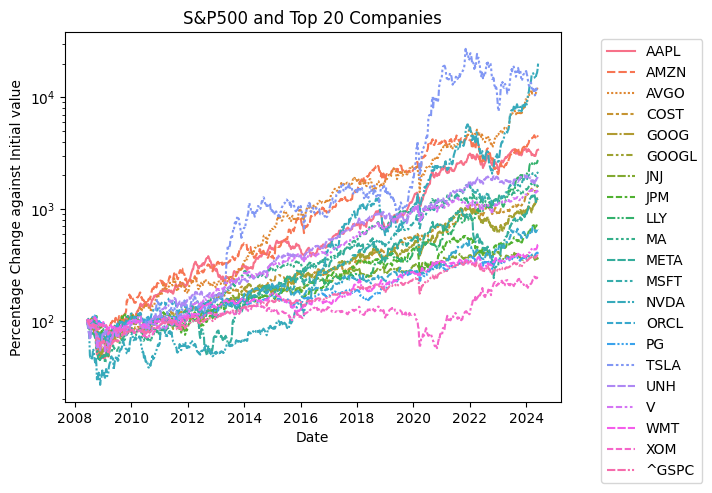

In [ ]:
sns.lineplot(stocks_pct)
plt.yscale('log')
plt.xlabel('Date')
plt.ylabel('Percentage Change against Initial value')
plt.title('S&P500 and Top 20 Companies')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.show()

In [ ]:
# shows an overall up trend
# the trends are not stationary

## Stationary Check

In [ ]:
# check for stationary using adfuller or Augmented Dickey-Fuller test
stationary = pd.DataFrame()
for ticker in stocks_pct.columns:
    result = adfuller(stocks_pct[ticker].dropna())
    stationary[ticker] = [result[0], result[1]]

stationary = stationary.T
stationary.columns = ['ADF Statistic', 'p-value']
stationary['Stationary'] = stationary['p-value'].apply(lambda x: True if x <= 0.05 else False)
stationary

,ADF Statistic,p-value,Stationary
AAPL,1.291969,0.996564,False
AMZN,-0.093163,0.950115,False
AVGO,4.631637,1.000000,False
COST,2.595232,0.999074,False
GOOG,0.648265,0.988747,False
GOOGL,0.660668,0.989019,False
JNJ,-0.806103,0.817323,False
JPM,0.833712,0.992161,False
LLY,7.338780,1.000000,False
MA,1.812112,0.998373,False


In [ ]:
# All the top 20 companies have very high p-value,
# which suggests that the trends are non-stationary,
# which is expected as the trend chart earlier shows an overall up trend

## Check for Cointegration

In [ ]:
# two non-stationary trends are said to cointegrate if one trend can be described as a linear combination of the other
# thus, a linear regression is used

coin = pd.DataFrame()
def cointegration(company):
  # prepare the data
  data = stocks_pct[['^GSPC', company]].dropna()
  X = data[company].values.reshape(-1, 1)
  Y = data['^GSPC'].values

  # ensure X and Y have the same number of samples after handling missing data
  min_length = min(len(X), len(Y))
  X = X[:min_length]
  Y = Y[:min_length]

  # fit and predict
  model = LinearRegression().fit(X, Y)
  Y_pred = model.predict(X)

  # print regression coefficients
  print(f'\n{company}')
  print(f'Intercept: {model.intercept_}')
  print(f'Slope: {model.coef_[0]}')

  # Get residuals
  residuals = Y - Y_pred
  residuals = residuals.flatten()

  # perform ADF test on residuals
  adf_result = adfuller(residuals)
  print('ADF Statistic:', adf_result[0])
  print('p-value:', adf_result[1])

  # interpret the results
  if adf_result[1] <= 0.05:
      print('The residuals are stationary, indicating cointegration.')
  else:
      print('The residuals are not stationary, indicating no cointegration.')

  return adf_result

In [ ]:
cointegrated_companies = []
for company in stocks_pct.columns[1:]:
  adf_result = cointegration(company)
  if adf_result[1] < 0.05:
    cointegrated_companies.append(company)

print(f'\nCointegrated companies: {cointegrated_companies}')


AMZN
Intercept: 91.7977216128208
Slope: 0.05778420809628253
ADF Statistic: -2.094892588566564
p-value: 0.24657327072290952
The residuals are not stationary, indicating no cointegration.

AVGO
Intercept: 121.24253302255453
Slope: 0.031310780902719444
ADF Statistic: -0.23324608684717188
p-value: 0.9344409986920632
The residuals are not stationary, indicating no cointegration.

COST
Intercept: 82.7245140312581
Slope: 0.23075513930074368
ADF Statistic: -1.1214964376309264
p-value: 0.7064236925955832
The residuals are not stationary, indicating no cointegration.

GOOG
Intercept: 74.18698455480391
Slope: 0.281928380638461
ADF Statistic: -2.626072023099229
p-value: 0.08772753866246924
The residuals are not stationary, indicating no cointegration.

GOOGL
Intercept: 72.87320777780502
Slope: 0.2865618270293005
ADF Statistic: -2.702263734602774
p-value: 0.07364736260933853
The residuals are not stationary, indicating no cointegration.

JNJ
Intercept: -2.7480374580951548
Slope: 0.7941719319257178

In [ ]:
# it seems there are only 3 companies among the top 20 that cointegrate with S&P500 as a whole
# This means that there is a dog-leash relationship between the two related indicators
# let us find out who is the dominant one

# create a VAR model; vector autogression
model = VAR(stocks_pct[['^GSPC'] + cointegrated_companies])

# fit the model and select the best lag length
lag_order = model.select_order(maxlags=4)  # limited to 1 month lag; weekly granularity

# choose the lag length with the minimum information criterion
optimal_lag = lag_order.aic  # or .bic or .hqic
print(f"Optimal lag length based on AIC: {optimal_lag}")

Optimal lag length based on AIC: 4


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


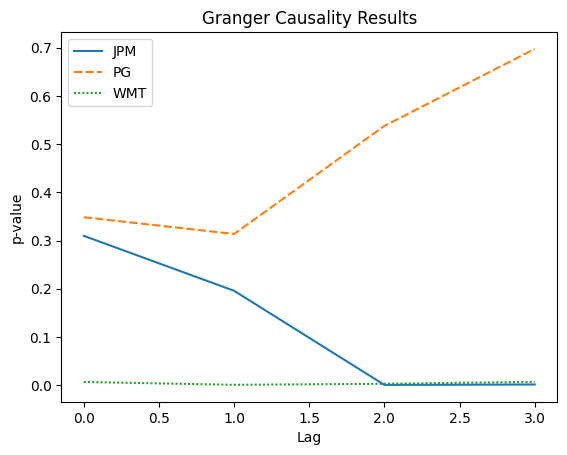

In [ ]:
max_lag = optimal_lag
results = {}

for company in cointegrated_companies:
    result = grangercausalitytests(stocks_pct[['^GSPC', company]], max_lag, verbose=False)
    p_values = [round(test[0]['ssr_chi2test'][1], 4) for test in result.values()]
    results[company] = p_values

results = pd.DataFrame(results)

sns.lineplot(data=results)
plt.xlabel('Lag')
plt.ylabel('p-value')
plt.title('Granger Causality Results')
plt.show()

In [ ]:
# p-values less than 0.05 suggest that only JPM and WMT granger-cause S&P500 to change
# i.e., if JPM goes up, S&P500 is also likely to go up

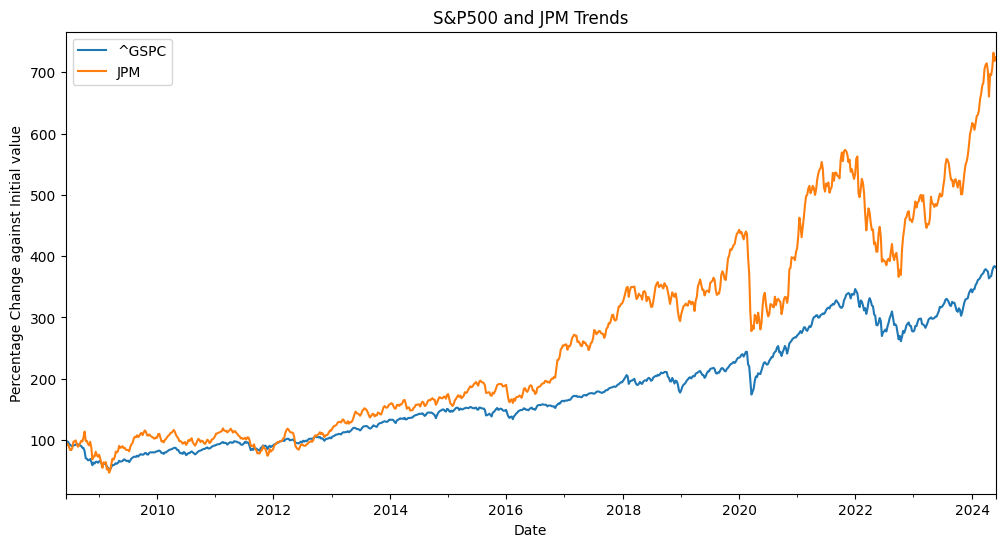

In [ ]:
# visual confirmation
stocks_pct[['^GSPC', 'JPM']].plot(figsize=(12, 6))
plt.xlabel('Date')
plt.ylabel('Percentage Change against Initial value')
plt.title('S&P500 and JPM Trends')
plt.show()

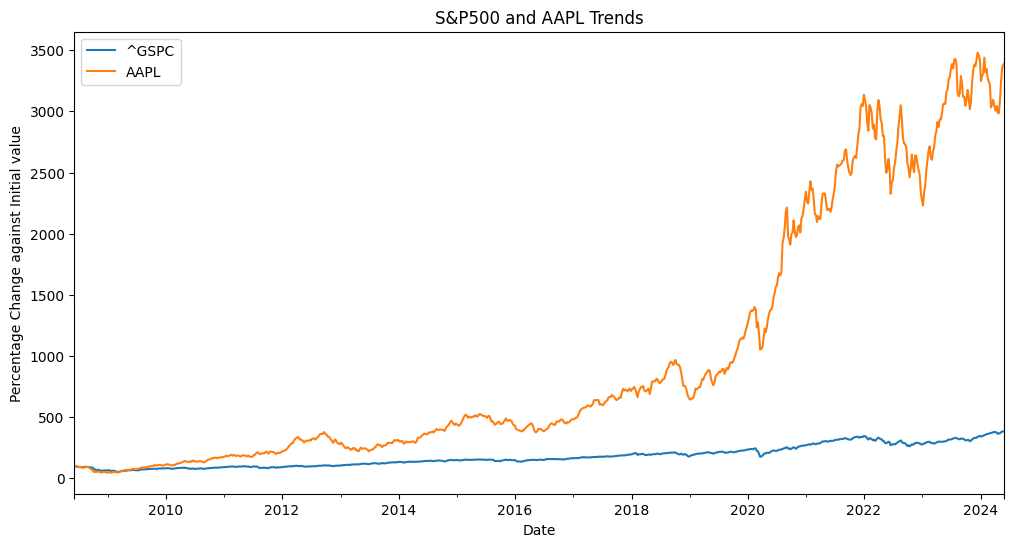

In [ ]:
# in contrast, Apple trend does not cointegrate with S&P500
stocks_pct[['^GSPC', 'AAPL']].plot(figsize=(12, 6))
plt.title('S&P500 and AAPL Trends')
plt.xlabel('Date')
plt.ylabel('Percentage Change against Initial value')
plt.show()

In [ ]:
# we first planned to find news about cointegrating companies and find out whether those news affect S&P500 as expected, but JP Morgan is an investment banking firm and Walmart is a gorcery merchandise
# meaning, there aren't much news about them
# thus general news will be used for the analysis

# News

In [ ]:
# time to get the news
od.download("https://www.kaggle.com/datasets/aaron7sun/stocknews")
od.download("https://www.kaggle.com/datasets/myrios/new-york-times-news-from-2016-to-2022/data")
od.download("https://www.kaggle.com/datasets/gpreda/bbc-news")
#myrios
#Kaggle api key
#DO NOT SHARE THE API KEY WITH OTHERS

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: myrios
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/aaron7sun/stocknews


100%|██████████| 5.82M/5.82M [00:00<00:00, 44.1MB/s]

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: myrios
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/myrios/new-york-times-news-from-2016-to-2022


100%|██████████| 16.8M/16.8M [00:00<00:00, 71.3MB/s]



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: myrios
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/gpreda/bbc-news


100%|██████████| 3.25M/3.25M [00:00<00:00, 191MB/s]

In [ ]:
news1 = pd.read_csv('/content/stocknews/RedditNews.csv', index_col='Date')
news1.head()

,News
Date,
2016-07-01,A 117-year-old woman in Mexico City finally re...
2016-07-01,IMF chief backs Athens as permanent Olympic host
2016-07-01,"The president of France says if Brexit won, so..."
2016-07-01,British Man Who Must Give Police 24 Hours' Not...
2016-07-01,100+ Nobel laureates urge Greenpeace to stop o...


In [ ]:
news2 = pd.read_csv("/content/new-york-times-news-from-2016-to-2022/NYT_2016_to_2022.csv", index_col='pub_date')
news2.head()

,abstract
pub_date,
2016-07-01,Judge Pratt’s decision is the first in a feder...
2016-07-01,A selected guide to concerts in the New York C...
2016-07-01,All eyes are on the Hershey Trust Company agai...
2016-07-01,Friends and family members went to the Church ...
2016-07-01,"The Battle of the Somme, a century ago, left i..."


In [ ]:
news3 = pd.read_csv('/content/bbc-news/bbc_news.csv', index_col='pubDate')
news3.head()

,title,guid,link,description
pubDate,,,,
"Mon, 07 Mar 2022 08:01:56 GMT",Ukraine: Angry Zelensky vows to punish Russian...,https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
"Sun, 06 Mar 2022 22:49:58 GMT",War in Ukraine: Taking cover in a town under a...,https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
"Mon, 07 Mar 2022 00:14:42 GMT",Ukraine war 'catastrophic for global food',https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
"Mon, 07 Mar 2022 00:05:40 GMT",Manchester Arena bombing: Saffie Roussos's par...,https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
"Mon, 07 Mar 2022 08:15:53 GMT",Ukraine conflict: Oil price soars to highest l...,https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


In [ ]:
# description column alone should be enough from news2
news3 = news3[['description']]

# rename the columns for consistency
news1.rename(columns={'Date': 'date', 'News': 'news'}, inplace=True)
news2.rename(columns={'pub_date': 'date', 'abstract': 'news'}, inplace=True)
news3.rename(columns={'pubDate': 'date', 'description': 'news'}, inplace=True)

print(news1.info())
print('\n')
print(news2.info())
print('\n')
print(news3.info())

<class 'pandas.core.frame.DataFrame'>
Index: 73608 entries, 2016-07-01 to 2008-06-08
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   news    73608 non-null  object
dtypes: object(1)
memory usage: 1.1+ MB
None


<class 'pandas.core.frame.DataFrame'>
Index: 323273 entries, 2016-07-01 to 2022-03-07
Data columns (total 1 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   news    323273 non-null  object
dtypes: object(1)
memory usage: 4.9+ MB
None


<class 'pandas.core.frame.DataFrame'>
Index: 37673 entries, Mon, 07 Mar 2022 08:01:56 GMT to Sun, 11 Aug 2024 21:00:08 GMT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   news    37673 non-null  object
dtypes: object(1)
memory usage: 588.6+ KB
None


<ipython-input-44-caed2d907c76>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  news3.rename(columns={'pubDate': 'date', 'description': 'news'}, inplace=True)


In [ ]:
# change the dates to datetime object
news1.index = pd.to_datetime(news1.index)
news2.index = pd.to_datetime(news2.index)
news3.index = pd.to_datetime(news3.index, format='%a, %d %b %Y %H:%M:%S %Z').strftime('%Y-%m-%d')

In [ ]:
# combine the three news datasets
news = pd.concat([news1, news2, news3])
news.head()

,news
2016-07-01 00:00:00,A 117-year-old woman in Mexico City finally re...
2016-07-01 00:00:00,IMF chief backs Athens as permanent Olympic host
2016-07-01 00:00:00,"The president of France says if Brexit won, so..."
2016-07-01 00:00:00,British Man Who Must Give Police 24 Hours' Not...
2016-07-01 00:00:00,100+ Nobel laureates urge Greenpeace to stop o...


In [ ]:
# datetime format is somehow lost
# let us convert it back
news.reset_index(inplace=True)
news.rename(columns={'index': 'date'}, inplace=True)
news.date = pd.to_datetime(news.date)
news.sort_values(by='date', inplace=True, ignore_index=True)
print(news.info())
news.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434554 entries, 0 to 434553
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    434554 non-null  datetime64[ns]
 1   news    434554 non-null  object        
dtypes: datetime64[ns](1), object(1)
memory usage: 6.6+ MB
None


,date,news
0,2007-07-07,It was a long antipodean night. While there’s ...
1,2007-07-07,A record-breaking heat wave in the Southwest i...
2,2007-07-07,The Lewis Hamilton effect is felt everywhere. ...
3,2007-07-07,England started its Live Earth concert at Wemb...
4,2007-07-07,The Sam’s Army ratings polls reflect the gener...


In [ ]:
# time to determine the sentiment

# using vader model from nltk
nltk.download('vader_lexicon') # get vader model
sia = SentimentIntensityAnalyzer() # nlp model

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [ ]:
# test
sia.polarity_scores('I love data preparation and visualization')

{'neg': 0.0, 'neu': 0.488, 'pos': 0.512, 'compound': 0.6369}

In [ ]:
# apply on actual data
# it takes 2.5 minutes to run
tqdm.pandas(desc="Calculating Sentiment")
news['sentiment_nltk'] = news['news'].progress_apply(lambda x: sia.polarity_scores(x))
news.head()

Calculating Sentiment:   0%|          | 0/434554 [00:00<?, ?it/s]

,date,news,sentiment_nltk
0,2007-07-07,It was a long antipodean night. While there’s ...,"{'neg': 0.059, 'neu': 0.878, 'pos': 0.064, 'co..."
1,2007-07-07,A record-breaking heat wave in the Southwest i...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound..."
2,2007-07-07,The Lewis Hamilton effect is felt everywhere. ...,"{'neg': 0.0, 'neu': 0.965, 'pos': 0.035, 'comp..."
3,2007-07-07,England started its Live Earth concert at Wemb...,"{'neg': 0.033, 'neu': 0.945, 'pos': 0.022, 'co..."
4,2007-07-07,The Sam’s Army ratings polls reflect the gener...,"{'neg': 0.102, 'neu': 0.786, 'pos': 0.112, 'co..."


In [ ]:
#split into individual columns
sentiment = pd.json_normalize(news['sentiment_nltk'])
sentiment.head()

,neg,neu,pos,compound
0,0.059,0.878,0.064,0.0516
1,0.000,1.000,0.000,0.0000
2,0.000,0.965,0.035,0.3612
3,0.033,0.945,0.022,-0.1779
4,0.102,0.786,0.112,0.3400


In [ ]:
# concat back with original news
news = pd.concat([news, sentiment], axis=1)
news.drop('sentiment_nltk', axis=1, inplace=True)
news.head()

,date,news,neg,neu,pos,compound
0,2007-07-07,It was a long antipodean night. While there’s ...,0.059,0.878,0.064,0.0516
1,2007-07-07,A record-breaking heat wave in the Southwest i...,0.000,1.000,0.000,0.0000
2,2007-07-07,The Lewis Hamilton effect is felt everywhere. ...,0.000,0.965,0.035,0.3612
3,2007-07-07,England started its Live Earth concert at Wemb...,0.033,0.945,0.022,-0.1779
4,2007-07-07,The Sam’s Army ratings polls reflect the gener...,0.102,0.786,0.112,0.3400


In [ ]:
# most news articles have a high neutral score
# which is expected as news are meant to inform the public and remain neutral
news[news['compound'] == 0]

,date,news,neg,neu,pos,compound
1,2007-07-07,A record-breaking heat wave in the Southwest i...,0.0,1.0,0.0,0.0
8,2008-06-08,b'Town in Britain Plans to Start its Own Curre...,0.0,1.0,0.0,0.0
10,2008-06-08,"b'News is a contraband item in Pakistan now, a...",0.0,1.0,0.0,0.0
12,2008-06-08,b'Chiapas: army occupies Zapatista communities...,0.0,1.0,0.0,0.0
13,2008-06-08,"b""Canada: Beware slippery slope' to censorship...",0.0,1.0,0.0,0.0
...,...,...,...,...,...,...
434543,2024-08-11,The Perseids meteor shower peaks between Augus...,0.0,1.0,0.0,0.0
434544,2024-08-11,A community group has sprung up in England's n...,0.0,1.0,0.0,0.0
434547,2024-08-11,"Celebrities Snoop Dogg, David Beckham, Jessica...",0.0,1.0,0.0,0.0
434548,2024-08-11,"The new sporting events, the venues, the stars...",0.0,1.0,0.0,0.0


In [ ]:
# this is way too much neutral articles, which could affect our analysis
# let me just use a more powerful language model to do analyze the sentiment
# it will run locally :) with RoBERTa model
neutral_news = news[news['compound'] == 0]
neutral_news[['date', 'news']].to_csv('neutral_news.csv', index=False)

# below is the code; do not run it here; thanks
# first model to get positive, negative and neutral scores
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# from scipy.special import softmax

# # using roberta model
# MODEL = f"cardiffnlp/twitter-roberta-base-sentiment"
# tokenizer = AutoTokenizer.from_pretrained(MODEL)
# model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# # second model to get label and compound score
# from transformers import pipeline
# sent_pipeline = pipeline("sentiment-analysis")

# import pandas as pd
# news = pd.read_csv("/Users/myrios/Downloads/news.csv")
# news.info()

# # act on first 1000 data for testing
# def sent_analysis(text):
#   encoded_text = tokenizer(text, return_tensors='pt')
#   output = model(**encoded_text)
#   scores = output[0][0].detach().numpy()
#   scores = softmax(scores)
#   sentiment = sent_pipeline(text)[0]
#   scores_dict = {
#     'negative': scores[0],
#     'neutral': scores[1],
#     'positive': scores[2],
#   }
#   return scores_dict, sentiment

# first_five = pd.DataFrame()
# first_five['sentiment'] = news['news'].head(1000).apply(sent_analysis)
# first_five.head()

# def sent_analysis(text):
#   try:
#     encoded_text = tokenizer(text, return_tensors='pt')
#     output = model(**encoded_text)
#     scores = output[0][0].detach().numpy()
#     scores = softmax(scores)
#     sentiment = sent_pipeline(text)[0]
#     scores_dict = {
#       'negative': scores[0],
#       'neutral': scores[1],
#       'positive': scores[2],
#     }
#     return scores_dict, sentiment
#   except RuntimeError:
#     return np.nan, np.nan

# neutral_news['sentiment'] = neutral_news['news'].apply(lambda x: sent_analysis(x))
# neutral_news.head()

In [ ]:
# locally run for 2 hrs and we are back with the data
od.download("https://www.kaggle.com/datasets/myrios/fraction-of-news-sentiment")
neu_news = pd.read_csv('/content/fraction-of-news-sentiment/neutral_news_results.csv')
neu_news.head()
#myrios
#Kaggle api key
#DO NOT SHARE THE API KEY WITH OTHERS

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: myrios
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/myrios/fraction-of-news-sentiment


100%|██████████| 9.36M/9.36M [00:00<00:00, 40.4MB/s]


,Unnamed: 0,date,news,sentiment
0,0,2007-07-07,A record-breaking heat wave in the Southwest i...,"({'negative': 0.19750476, 'neutral': 0.6614898..."
1,1,2008-06-08,b'Town in Britain Plans to Start its Own Curre...,"({'negative': 0.029850129, 'neutral': 0.916916..."
2,2,2008-06-08,"b'News is a contraband item in Pakistan now, a...","({'negative': 0.64336276, 'neutral': 0.3440932..."
3,3,2008-06-08,b'Chiapas: army occupies Zapatista communities...,"({'negative': 0.24157748, 'neutral': 0.7353354..."
4,4,2008-06-08,"b""Canada: Beware slippery slope' to censorship...","({'negative': 0.60930634, 'neutral': 0.3750881..."


In [ ]:
neu_news['sentiment'].iloc[0]

"({'negative': 0.19750476, 'neutral': 0.6614898, 'positive': 0.14100547}, {'label': 'POSITIVE', 'score': 0.9974910020828247})"

In [ ]:
# drop the unnecessary column
neu_news.drop('Unnamed: 0', axis=1, inplace=True)

# split the sentiment tuple to two separate columns
scores = []
labels = []

for i in range(neu_news.shape[0]):
  try:
    tup = ast.literal_eval(neu_news['sentiment'].iloc[i]) # convert string to tuple
  except ValueError:
    tup = (np.nan,np.nan)
  scores.append(tup[0])
  labels.append(tup[1])

neu_news['score_col'] = scores
neu_news['label_col'] = labels

neu_news.head()

,date,news,sentiment,score_col,label_col
0,2007-07-07,A record-breaking heat wave in the Southwest i...,"({'negative': 0.19750476, 'neutral': 0.6614898...","{'negative': 0.19750476, 'neutral': 0.6614898,...","{'label': 'POSITIVE', 'score': 0.9974910020828..."
1,2008-06-08,b'Town in Britain Plans to Start its Own Curre...,"({'negative': 0.029850129, 'neutral': 0.916916...","{'negative': 0.029850129, 'neutral': 0.9169163...","{'label': 'NEGATIVE', 'score': 0.9440157413482..."
2,2008-06-08,"b'News is a contraband item in Pakistan now, a...","({'negative': 0.64336276, 'neutral': 0.3440932...","{'negative': 0.64336276, 'neutral': 0.34409323...","{'label': 'NEGATIVE', 'score': 0.9920668601989..."
3,2008-06-08,b'Chiapas: army occupies Zapatista communities...,"({'negative': 0.24157748, 'neutral': 0.7353354...","{'negative': 0.24157748, 'neutral': 0.7353354,...","{'label': 'NEGATIVE', 'score': 0.9435353875160..."
4,2008-06-08,"b""Canada: Beware slippery slope' to censorship...","({'negative': 0.60930634, 'neutral': 0.3750881...","{'negative': 0.60930634, 'neutral': 0.37508816...","{'label': 'NEGATIVE', 'score': 0.967464029788971}"


In [ ]:
# split the two columns again
scores = pd.json_normalize(neu_news['score_col'])
labels = pd.json_normalize(neu_news['label_col'])
neu_news = pd.concat([neu_news, scores, labels], axis=1)
neu_news.drop(['sentiment', 'score_col', 'label_col'], axis=1, inplace=True)
neu_news.rename(columns={'negative': 'neg', 'neutral': 'neu', 'positive': 'pos', 'label': 'sentiment', 'score': 'compound'}, inplace=True)
neu_news.head()

,date,news,neg,neu,pos,sentiment,compound
0,2007-07-07,A record-breaking heat wave in the Southwest i...,0.197505,0.661490,0.141005,POSITIVE,0.997491
1,2008-06-08,b'Town in Britain Plans to Start its Own Curre...,0.029850,0.916916,0.053234,NEGATIVE,0.944016
2,2008-06-08,"b'News is a contraband item in Pakistan now, a...",0.643363,0.344093,0.012544,NEGATIVE,0.992067
3,2008-06-08,b'Chiapas: army occupies Zapatista communities...,0.241577,0.735335,0.023087,NEGATIVE,0.943535
4,2008-06-08,"b""Canada: Beware slippery slope' to censorship...",0.609306,0.375088,0.015605,NEGATIVE,0.967464


In [ ]:
# check if there are still neutral news
neu_news['sentiment'].value_counts()

,count
sentiment,
POSITIVE,62471
NEGATIVE,61835


In [ ]:
# drop the neutral news from the original news df
news = news.drop(news[news['compound'] == 0].index)

# add sentiment label for news
news['sentiment'] = news['compound'].apply(lambda x: 'POSITIVE' if x > 0 else ('NEGATIVE' if x < 0 else 'NEUTRAL')) # neutral is not expected but added as a ref
news.head()

,date,news,neg,neu,pos,compound,sentiment
0,2007-07-07,It was a long antipodean night. While there’s ...,0.059,0.878,0.064,0.0516,POSITIVE
2,2007-07-07,The Lewis Hamilton effect is felt everywhere. ...,0.000,0.965,0.035,0.3612,POSITIVE
3,2007-07-07,England started its Live Earth concert at Wemb...,0.033,0.945,0.022,-0.1779,NEGATIVE
4,2007-07-07,The Sam’s Army ratings polls reflect the gener...,0.102,0.786,0.112,0.3400,POSITIVE
5,2007-07-07,The government has until Monday to protect the...,0.000,0.894,0.106,0.3818,POSITIVE


In [ ]:
# reorder neu_new columns
neu_news = neu_news[['date', 'news', 'neg', 'neu', 'pos', 'compound', 'sentiment']]

# concat news with neutral news
news = pd.concat([news, neu_news])

news['date'] = pd.to_datetime(news['date']) # convert back to datetime because it keeps going back to string
news.sort_values(by='date', inplace=True, ignore_index=True)
print(news.info())
news.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434449 entries, 0 to 434448
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       434449 non-null  datetime64[ns]
 1   news       434449 non-null  object        
 2   neg        434448 non-null  float64       
 3   neu        434448 non-null  float64       
 4   pos        434448 non-null  float64       
 5   compound   434448 non-null  float64       
 6   sentiment  434448 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 23.2+ MB
None


,date,news,neg,neu,pos,compound,sentiment
0,2007-07-07,It was a long antipodean night. While there’s ...,0.059000,0.87800,0.064000,0.051600,POSITIVE
1,2007-07-07,In Mexico there are no licensing or registrati...,0.044000,0.95600,0.000000,-0.296000,NEGATIVE
2,2007-07-07,The government has until Monday to protect the...,0.000000,0.89400,0.106000,0.381800,POSITIVE
3,2007-07-07,A record-breaking heat wave in the Southwest i...,0.197505,0.66149,0.141005,0.997491,POSITIVE
4,2007-07-07,England started its Live Earth concert at Wemb...,0.033000,0.94500,0.022000,-0.177900,NEGATIVE


In [ ]:
# because the change in stocks are in weekly granularity
# and we want to compare it with the news within the same week
# the dates of the news will be changed to the date at the start of each week
# so that Power BI can connect a relation between the two

news['date'] = news['date'].dt.to_period('W-SUN').dt.start_time
news.head()

,date,news,neg,neu,pos,compound,sentiment
0,2007-07-02,It was a long antipodean night. While there’s ...,0.059000,0.87800,0.064000,0.051600,POSITIVE
1,2007-07-02,In Mexico there are no licensing or registrati...,0.044000,0.95600,0.000000,-0.296000,NEGATIVE
2,2007-07-02,The government has until Monday to protect the...,0.000000,0.89400,0.106000,0.381800,POSITIVE
3,2007-07-02,A record-breaking heat wave in the Southwest i...,0.197505,0.66149,0.141005,0.997491,POSITIVE
4,2007-07-02,England started its Live Earth concert at Wemb...,0.033000,0.94500,0.022000,-0.177900,NEGATIVE


In [ ]:
# confirmation
ran_int = random.randint(0, news.shape[0])
print(f"Index: {ran_int}")
print(news.iloc[ran_int]['news'])
print("Sentiment: ", news.iloc[ran_int]['sentiment'])

Index: 99807
The magazine’s Ethicist columnist on whether parents must contribute to a public school’s fundraising program and whether to call out a nephew for his multiple marriages.
Sentiment:  NEGATIVE


# Risk Management Metrics

In [ ]:
# returns, weekly returns in this case, are the difference in stock prices between this week and last week
# calculate daily returns
returns = stocks.pct_change()

# volatility is the variations, or standard deviations, of returns
# annualized mean of return and volatility
annualized_return = returns.mean() * 52 # weekly to annual
annualized_volatility = returns.std() * np.sqrt(52) # weekly to annual

return_volatility = pd.DataFrame({'Annualized Return': annualized_return,
                                  'Annualized Volatility': annualized_volatility})

return_volatility.head()

,Annualized Return,Annualized Volatility
Ticker,,
AAPL,0.249081,0.239556
AMZN,0.278637,0.290458
AVGO,0.356190,0.263010
COST,0.188376,0.168478
GOOG,0.181382,0.222154


In [ ]:
# value at Risk (VaR) at 95% confidence level
VaR_95 = returns.quantile(0.05) * np.sqrt(52) # taking first 0.05 quantile as the wrost possible return

var_data = pd.DataFrame({'VaR_95': VaR_95})
var_data.head()

,VaR_95
Ticker,
AAPL,-0.370420
AMZN,-0.403590
AVGO,-0.367441
COST,-0.249844
GOOG,-0.338184


In [ ]:
metrics = pd.DataFrame({
    'Ticker': returns.columns,
    'Annualized Return': annualized_return.values,
    'Annualized Volatility': annualized_volatility.values,
    'VaR_95': VaR_95.values,
})

metrics.head()

,Ticker,Annualized Return,Annualized Volatility,VaR_95
0,AAPL,0.249081,0.239556,-0.370420
1,AMZN,0.278637,0.290458,-0.403590
2,AVGO,0.356190,0.263010,-0.367441
3,COST,0.188376,0.168478,-0.249844
4,GOOG,0.181382,0.222154,-0.338184


# Summary

## Stocks Trends

The percentage change in stock prices of the top 20 companies will be used to analyze the price trends against news sentiment.

In [ ]:
stocks_pct.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 835 entries, 2008-06-08 to 2024-06-02
Freq: W-SUN
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    835 non-null    float64
 1   AMZN    835 non-null    float64
 2   AVGO    774 non-null    float64
 3   COST    835 non-null    float64
 4   GOOG    835 non-null    float64
 5   GOOGL   835 non-null    float64
 6   JNJ     835 non-null    float64
 7   JPM     835 non-null    float64
 8   LLY     835 non-null    float64
 9   MA      835 non-null    float64
 10  META    629 non-null    float64
 11  MSFT    835 non-null    float64
 12  NVDA    835 non-null    float64
 13  ORCL    835 non-null    float64
 14  PG      835 non-null    float64
 15  TSLA    727 non-null    float64
 16  UNH     835 non-null    float64
 17  V       835 non-null    float64
 18  WMT     835 non-null    float64
 19  XOM     835 non-null    float64
 20  ^GSPC   835 non-null    float64
dtypes: float

In [ ]:
# data types are correct

# reset index to export index as date column
stocks_pct.reset_index(inplace=True)
stocks_pct.rename(columns={'index': 'Date'}, inplace=True)
stocks_pct.head()

,Date,AAPL,AMZN,AVGO,COST,GOOG,GOOGL,JNJ,JPM,LLY,...,MSFT,NVDA,ORCL,PG,TSLA,UNH,V,WMT,XOM,^GSPC
0,2008-06-08,100.000000,100.000000,NaN,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,NaN,100.000000,100.000000,100.000000,100.000000,100.000000
1,2008-06-15,95.917267,96.233231,NaN,98.120109,96.997021,96.997021,98.758049,91.657839,98.677904,...,101.148520,90.164867,97.783437,100.783567,NaN,94.369702,93.320930,101.836218,101.290868,97.832661
2,2008-06-22,95.863607,101.368618,NaN,97.867212,98.028469,98.028468,97.597282,93.442700,97.747053,...,103.546664,82.897226,98.747164,98.633301,NaN,86.190962,97.590677,99.587377,99.947176,97.167228
3,2008-06-29,92.532166,96.267632,NaN,97.754807,93.987769,93.987767,96.866538,88.458561,96.037724,...,100.715119,80.214911,95.996156,94.764022,NaN,77.988507,94.762792,98.070970,99.956352,94.359942
4,2008-07-06,91.284486,89.190503,NaN,100.826866,92.630903,92.630899,97.277770,83.832839,95.416836,...,95.926046,69.713311,91.838979,94.587102,NaN,74.053226,93.084303,97.280984,101.109391,92.127910


In [ ]:
# transpose the table into a power bi friendly format
stocks_trends = stocks_pct.melt(id_vars=['Date'], var_name='Ticker', value_name='Overall PCT Change')
# so that filter works on Ticker, and relations between tables can be connected on Ticker
stocks_trends.head()

,Date,Ticker,Overall PCT Change
0,2008-06-08,AAPL,100.000000
1,2008-06-15,AAPL,95.917267
2,2008-06-22,AAPL,95.863607
3,2008-06-29,AAPL,92.532166
4,2008-07-06,AAPL,91.284486


In [ ]:
# duplicate check
stocks_trends.duplicated().sum()

0

In [ ]:
# there are no duplicates

In [ ]:
# null check
stocks_trends.isnull().sum()

,0
Date,0
Ticker,0
Overall PCT Change,375


In [ ]:
# power bi doesn't work well with null values;
# if there are null values, Avg/Sum aggregation cannot be used
# since the companies did not exist or list in those null periods
# fillna(0) should be fine
stocks_trends.fillna(0, inplace=True)
assert stocks_trends.isnull().sum().sum() == 0

In [ ]:
# time to export
stocks_trends.to_csv('stocks_trends.csv', index=False)

## Risk Metrics

In [ ]:
metrics.head()

,Ticker,Annualized Return,Annualized Volatility,VaR_95
0,AAPL,0.249081,0.239556,-0.370420
1,AMZN,0.278637,0.290458,-0.403590
2,AVGO,0.356190,0.263010,-0.367441
3,COST,0.188376,0.168478,-0.249844
4,GOOG,0.181382,0.222154,-0.338184


In [ ]:
# already in a power bi friendly format

metrics.isna().sum()

,0
Ticker,0
Annualized Return,0
Annualized Volatility,0
VaR_95,0


In [ ]:
metrics.duplicated().sum()

0

In [ ]:
# save
metrics.to_csv('metrics.csv', index=False)

## news

News sentiment analysis is the highlight of this whole analysis :)

In [ ]:
news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 434449 entries, 0 to 434448
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       434449 non-null  datetime64[ns]
 1   news       434449 non-null  object        
 2   neg        434448 non-null  float64       
 3   neu        434448 non-null  float64       
 4   pos        434448 non-null  float64       
 5   compound   434448 non-null  float64       
 6   sentiment  434448 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 23.2+ MB


In [ ]:
# correct data types

# take news starting from the start date to match with stocks
news.set_index('date', inplace=True)
news = news.loc[start_date:]
news.head()

,news,neg,neu,pos,compound,sentiment
date,,,,,,
2008-06-02,"b""Canada: Beware slippery slope' to censorship...",0.609306,0.375088,0.015605,0.967464,NEGATIVE
2008-06-02,"b""Oil reserves 'will last decades' - a BBC Sco...",0.238956,0.713291,0.047753,0.791826,NEGATIVE
2008-06-02,"b""A 5.1 earthquake hits China's Southern Qingh...",0.291053,0.683740,0.025207,0.947798,POSITIVE
2008-06-02,"b""Iceland opens Europe's largest national park...",0.004938,0.332221,0.662841,0.999515,POSITIVE
2008-06-02,b'Town in Britain Plans to Start its Own Curre...,0.029850,0.916916,0.053234,0.944016,NEGATIVE


In [ ]:
news['news'] = news['news'].str.replace('b"', ' ').str.replace("b'", ' ')
news.head()

,news,neg,neu,pos,compound,sentiment
date,,,,,,
2008-06-02,"Canada: Beware slippery slope' to censorship,...",0.609306,0.375088,0.015605,0.967464,NEGATIVE
2008-06-02,Oil reserves 'will last decades' - a BBC Scot...,0.238956,0.713291,0.047753,0.791826,NEGATIVE
2008-06-02,A 5.1 earthquake hits China's Southern Qingha...,0.291053,0.683740,0.025207,0.947798,POSITIVE
2008-06-02,Iceland opens Europe's largest national park....,0.004938,0.332221,0.662841,0.999515,POSITIVE
2008-06-02,Town in Britain Plans to Start its Own Currency',0.029850,0.916916,0.053234,0.944016,NEGATIVE


In [ ]:
# there may be some other nuances such as \n \t
# but left untreated as it does not affect the analysis

# dupli check
news.duplicated().sum()

19451

In [ ]:
# interesting how there are still duplicates with news
news[news.duplicated(keep=False)].head()

,news,neg,neu,pos,compound,sentiment
date,,,,,,
2008-06-09,German Papers Say 'Many Have Lost Faith in Am...,0.152000,0.662000,0.185000,0.128000,POSITIVE
2008-06-09,German Papers Say 'Many Have Lost Faith in Am...,0.152000,0.662000,0.185000,0.128000,POSITIVE
2008-06-30,28 Billion Bottles of Water [PIC]',0.112122,0.837333,0.050545,0.950349,NEGATIVE
2008-06-30,28 Billion Bottles of Water [PIC]',0.112122,0.837333,0.050545,0.950349,NEGATIVE
2008-08-11,Why Russias response to Georgia was right',0.047402,0.838948,0.113650,0.503111,POSITIVE


In [ ]:
# acutal duplicates
# since news are web-scrapped from several sources, this is to be expected
print(news.duplicated().sum()/news.shape[0])

0.044772374678323


In [ ]:
# deleting 4.5% of data won't affect the analysis
news.drop_duplicates(inplace=True)
assert news.duplicated().sum() == 0

# check null
news.isnull().sum()

,0
news,0
neg,1
neu,1
pos,1
compound,1
sentiment,1


In [ ]:
# there has been one row with no sentiment data
# it was during the local run with RoBERTa model
# debugging it now is out of our capabilites
# simply drop that row
news.dropna(inplace=True)
news.isnull().sum()

,0
news,0
neg,0
neu,0
pos,0
compound,0
sentiment,0


In [ ]:
# also, there are some random news
news['character_count'] = news['news'].apply(lambda x: len(x))
news[news['character_count'] < 20]

,news,neg,neu,pos,compound,sentiment,character_count
date,,,,,,,
2008-06-30,',0.150929,0.734895,0.114176,0.839008,POSITIVE,10
2008-07-07,Fascism [PIC]',0.595189,0.381898,0.022913,0.999251,NEGATIVE,15
2008-07-07,Tony Snow is Dead',0.589000,0.411000,0.000000,-0.648600,NEGATIVE,19
2008-07-14,muslim barbie ',0.086114,0.819651,0.094234,0.985848,NEGATIVE,16
2008-07-28,Beer Tourism',0.058380,0.826008,0.115612,0.622882,POSITIVE,14
...,...,...,...,...,...,...,...
2022-01-24,This isn’t goodbye.,0.255675,0.688597,0.055728,0.990234,POSITIVE,19
2022-01-24,Baby steps.,0.019516,0.494099,0.486385,0.999224,POSITIVE,11
2022-01-31,Obviously.,0.277870,0.485453,0.236677,0.989428,POSITIVE,10


In [ ]:
# it is better to drop these random news
news = news[news['character_count'] > 20]
news.drop('character_count', axis=1, inplace=True)
news.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 414470 entries, 2008-06-02 to 2024-08-12
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   news       414470 non-null  object 
 1   neg        414470 non-null  float64
 2   neu        414470 non-null  float64
 3   pos        414470 non-null  float64
 4   compound   414470 non-null  float64
 5   sentiment  414470 non-null  object 
dtypes: float64(4), object(2)
memory usage: 22.1+ MB


In [ ]:
# current news are either description or abstract
# which are long text and unsuitable for visualization on a dashboard
# thus, it is better to split up the words and make a word cloud

news['news'].iloc[10000]

" A poster promoting Israel as a tourist venue has been banned in the UK after it appeared to suggest areas such as the Gaza Strip were internationally recognised as part of its territory'"

In [ ]:
# download stopwords
nltk.download('stopwords')

# remove stop words
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    # remove non-alphabetic characters and convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text, re.I | re.A).lower()
    # split text into words and remove stop words
    words = [word for word in text.split() if word not in stop_words]
    return ' '.join(words)

tqdm.pandas()
news['processed_news'] = news['news'].progress_apply(preprocess_text) #1.5min to run

news.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


  0%|          | 0/414470 [00:00<?, ?it/s]

,news,neg,neu,pos,compound,sentiment,processed_news
date,,,,,,,
2008-06-02,"Canada: Beware slippery slope' to censorship,...",0.609306,0.375088,0.015605,0.967464,NEGATIVE,canada beware slippery slope censorship hearin...
2008-06-02,Oil reserves 'will last decades' - a BBC Scot...,0.238956,0.713291,0.047753,0.791826,NEGATIVE,oil reserves last decades bbc scotland investi...
2008-06-02,A 5.1 earthquake hits China's Southern Qingha...,0.291053,0.683740,0.025207,0.947798,POSITIVE,earthquake hits chinas southern qinghai province
2008-06-02,Iceland opens Europe's largest national park....,0.004938,0.332221,0.662841,0.999515,POSITIVE,iceland opens europes largest national park sq...
2008-06-02,Town in Britain Plans to Start its Own Currency',0.029850,0.916916,0.053234,0.944016,NEGATIVE,town britain plans start currency


In [ ]:
# get the weekly keywords

# resample numeric columns
resampled_numeric = news[news.select_dtypes(include='number').columns].resample('w').mean()

# resample non-numeric columns
def concatenate_strings(series):
    return ''.join(series)
resampled_non_numeric = news['processed_news'].resample('w').apply(concatenate_strings)

# combine
weekly_keywords = pd.concat([resampled_numeric, resampled_non_numeric], axis=1)

weekly_keywords.head()

,neg,neu,pos,compound,processed_news
date,,,,,
2008-06-08,0.273322,0.660467,0.066251,-0.098975,canada beware slippery slope censorship hearin...
2008-06-15,0.249438,0.674001,0.076578,0.104364,chew qat yemen per cent men per cent women che...
2008-06-22,0.269518,0.662085,0.068431,0.014857,man gunned stomps toddler deathiran withdraws ...
2008-06-29,0.286883,0.644383,0.068729,0.033257,cant submit positive news roadside bombs decli...
2008-07-06,0.236823,0.653914,0.109268,0.082914,army admits faulty iraq planningeu constitutio...


In [ ]:
# add avg sentiment label
weekly_keywords['sentiment'] = weekly_keywords['compound'].apply(lambda x: 'POSITIVE' if x > 0 else ('NEGATIVE' if x < 0 else 'NEUTRAL'))
weekly_keywords.head()

,neg,neu,pos,compound,processed_news,sentiment
date,,,,,,
2008-06-08,0.273322,0.660467,0.066251,-0.098975,canada beware slippery slope censorship hearin...,NEGATIVE
2008-06-15,0.249438,0.674001,0.076578,0.104364,chew qat yemen per cent men per cent women che...,POSITIVE
2008-06-22,0.269518,0.662085,0.068431,0.014857,man gunned stomps toddler deathiran withdraws ...,POSITIVE
2008-06-29,0.286883,0.644383,0.068729,0.033257,cant submit positive news roadside bombs decli...,POSITIVE
2008-07-06,0.236823,0.653914,0.109268,0.082914,army admits faulty iraq planningeu constitutio...,POSITIVE


In [ ]:
# take out keywords from original news
news.drop('processed_news', axis=1, inplace=True)
news.isna().sum()

,0
news,0
neg,0
neu,0
pos,0
compound,0
sentiment,0


In [ ]:
news.duplicated().sum()

0

In [ ]:
weekly_keywords.isna().sum()

,0
neg,0
neu,0
pos,0
compound,0
processed_news,0
sentiment,0


In [ ]:
weekly_keywords.duplicated().sum()

0

In [ ]:
# # rename date to Date for consistency

weekly_keywords.reset_index(inplace=True)
weekly_keywords.rename(columns={'date': 'Date'}, inplace=True)

news.reset_index(inplace=True)
news.rename(columns={'date': 'Date'}, inplace=True)

# time to export
news.to_csv('news.csv', index=False)
weekly_keywords.to_csv('weekly_keywords.csv', index=False)

## S&P500 Description

In [ ]:
top20.head()

,market_cap,Ticker,Name,Sector,Headquarters,Entity
0,3287734812672,AAPL,Apple Inc.,Information Technology,"Cupertino, California",Apple
1,3017962684416,MSFT,Microsoft,Information Technology,"Redmond, Washington",Microsoft
2,2576672096256,NVDA,Nvidia,Information Technology,"Santa Clara, California",Nvidia
3,2024390131712,GOOG,Alphabet Inc. (Class C),Communication Services,"Mountain View, California",Alphabet
4,2024385150976,GOOGL,Alphabet Inc. (Class A),Communication Services,"Mountain View, California",Alphabet


In [ ]:
top20.isna().sum()

,0
market_cap,0
Ticker,0
Name,0
Sector,0
Headquarters,0
Entity,0


In [ ]:
top20.duplicated().sum()

0

In [ ]:
# save
top20.to_csv('top20_description.csv', index=False)

## Download the files (optional)

In [ ]:
from google.colab import files
files.download('news.csv')
files.download('stocks_trends.csv')
files.download('top20_description.csv')
files.download('weekly_keywords.csv')
files.download('metrics.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>